# Appendix — 변수별 상세 탐색 및 보완 분석

> 주요 노트북(01~04)에서 다루지 않은 **추가 탐색 분석**을 수록합니다.
> 이 노트북은 독립적으로 실행할 수 있으며, `outputs/processed_healthcare_data.csv`가 미리 생성되어 있어야 합니다.

---

**수록 내용**
1. 검사 항목별 정상 범위 이탈 패턴 상세 분석  
2. 이상 소견 누적(Total_Abnormal_Count)의 분포 및 LOS와의 관계  
3. 피처 그룹별 LOS 상관도 비교  
4. 진단 코드 분포 분석 — Long-tail 구조 시각화  
5. 환자 단위 재입원 패턴 탐색  


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 전처리 완료 데이터 로드 (02_feature_engineering 실행 후 생성)
df = pd.read_csv('../outputs/processed_healthcare_data.csv', encoding='utf-8-sig')
print(f"데이터 로드 완료: {df.shape[0]}행 × {df.shape[1]}열")
df.head(3)


데이터 로드 완료: 372행 × 165열


,PatientID,AdmissionID,AdmissionStartDate,AdmissionEndDate,LengthOfStay,AdmissionYear,AdmissionMonth,AdmissionDayOfWeek,AdmissionDayName,LengthOfStayCategory,...,Lab_Trend_METABOLIC: SODIUM,Lab_Trend_METABOLIC: TOTAL PROTEIN,Lab_Trend_URINALYSIS: PH,Lab_Trend_URINALYSIS: RED BLOOD CELLS,Lab_Trend_URINALYSIS: SPECIFIC GRAVITY,Lab_Trend_URINALYSIS: WHITE BLOOD CELLS,LabTestCount,LabTestVariety,Total_Abnormal_Count,Total_Lab_Variability
0,7A025E77-7832-4F53-B9A7-09A3F98AC17E,7,2011-10-12 14:55:02.027,2011-10-22 01:16:07.557,9,2011,10,2,수,중기(8-14일),...,15.7,0.4,0.1,-0.3,0.0,3.7,230,35,34.0,6.985972
1,DCE5AEB8-6DB9-4106-8AE4-02CCC5C23741,1,1993-02-11 18:57:04.003,1993-02-24 17:22:29.713,12,1993,2,3,목,중기(8-14일),...,-14.1,1.3,-0.5,-1.4,0.0,1.1,355,35,49.0,8.480702
2,DCE5AEB8-6DB9-4106-8AE4-02CCC5C23741,2,2002-11-28 19:06:31.117,2002-12-04 19:14:40.797,6,2002,11,3,목,단기(4-7일),...,17.6,-1.8,-1.5,-0.2,0.0,0.3,202,35,28.0,6.837585


---
## 1. 검사 항목별 이상 소견 비율 상세 분석

각 검사 항목에서 이상 소견이 얼마나 자주 발생하는지 비교합니다.
이상 소견이 많은 검사 항목이 Total_Abnormal_Count에 더 크게 기여합니다.


array([<AxesSubplot:>, <AxesSubplot:>], dtype=object)

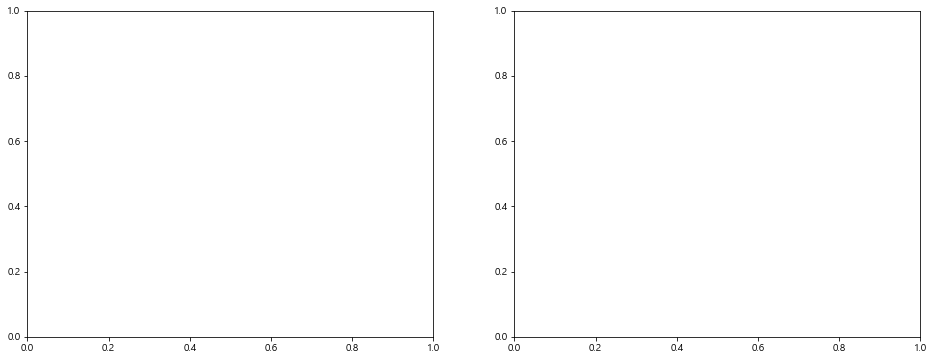

In [17]:
abnormal_cols = [c for c in df.columns if c.startswith('Abnormal_Sum_')]

# 검사명 추출 및 평균 이상 소견 횟수 계산
lab_names = [c.replace('Abnormal_Sum_', '') for c in abnormal_cols]
mean_abnormal = df[abnormal_cols].mean()
mean_abnormal.index = lab_names
mean_abnormal = mean_abnormal.sort_values(ascending=False)

# 상위 15개 시각화
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0]
axes[1]
axes[1]
axes

#mean_abnormal.head(15).plot(kind='barh', ax=axes[0], color='#E74C3C', alpha=0.8)

AttributeError: 'SubplotSpec' object has no attribute 'is_first_col'

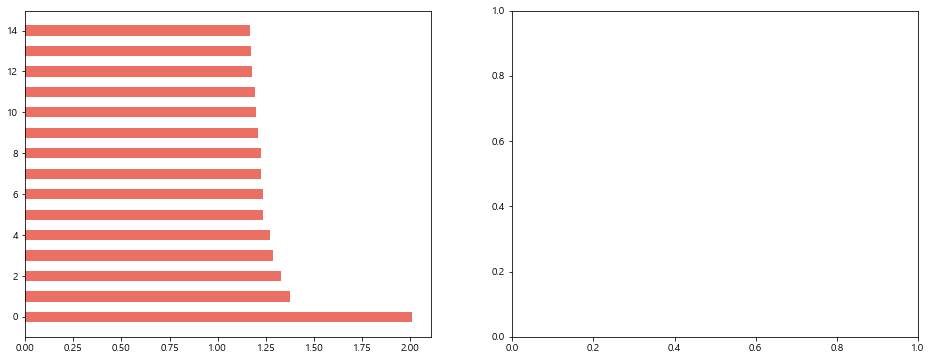

In [3]:
abnormal_cols = [c for c in df.columns if c.startswith('Abnormal_Sum_')]

# 검사명 추출 및 평균 이상 소견 횟수 계산
lab_names = [c.replace('Abnormal_Sum_', '') for c in abnormal_cols]
mean_abnormal = df[abnormal_cols].mean()
mean_abnormal.index = lab_names
mean_abnormal = mean_abnormal.sort_values(ascending=False)

# 상위 15개 시각화
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 절대값
mean_abnormal.head(15).plot(kind='barh', ax=axes[0], color='#E74C3C', alpha=0.8)
axes[0].set_title('검사 항목별 평균 이상 소견 횟수 (Top 15)', fontsize=12, weight='bold')
axes[0].set_xlabel('평균 이상 소견 횟수')
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

# 이상 소견 비율 (0보다 큰 입원 비율)
nonzero_rate = (df[abnormal_cols] > 0).mean()
nonzero_rate.index = lab_names
nonzero_rate = nonzero_rate.sort_values(ascending=False)

nonzero_rate.head(15).plot(kind='barh', ax=axes[1], color='#E67E22', alpha=0.8)
axes[1].set_title('이상 소견 발생 입원 비율 (Top 15)', fontsize=12, weight='bold')
axes[1].set_xlabel('발생 비율 (0~1)')
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3)

plt.suptitle('검사 항목별 이상 소견 패턴', fontsize=14, weight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"이상 소견 발생률 최상위 검사: {nonzero_rate.index[0]} ({nonzero_rate.iloc[0]:.1%})")


---
## 2. Total_Abnormal_Count 분포 및 LOS 관계

Total_Abnormal_Count는 SHAP 분석에서 전체 기여의 70.1%를 차지하는 핵심 변수입니다.
이 변수의 분포와 LOS와의 관계를 상세히 탐색합니다.


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 분포
axes[0].hist(df['Total_Abnormal_Count'], bins=30, color='#E74C3C', alpha=0.7, edgecolor='white')
axes[0].axvline(df['Total_Abnormal_Count'].mean(), color='navy', linestyle='--',
                label=f"평균: {df['Total_Abnormal_Count'].mean():.1f}")
axes[0].set_title('Total_Abnormal_Count 분포', fontsize=12, weight='bold')
axes[0].set_xlabel('전체 이상 소견 누적 횟수')
axes[0].legend()
axes[0].grid(alpha=0.3)

# LOS와 산점도
axes[1].scatter(df['Total_Abnormal_Count'], df['LengthOfStay'],
                alpha=0.4, color='#E74C3C', s=30)
corr = df['Total_Abnormal_Count'].corr(df['LengthOfStay'])
axes[1].set_title(f'Total_Abnormal_Count vs LOS\n상관계수: {corr:.3f}', fontsize=12, weight='bold')
axes[1].set_xlabel('Total_Abnormal_Count')
axes[1].set_ylabel('LengthOfStay (일)')
axes[1].grid(alpha=0.3)

# 4분위별 LOS 비교
df['TAC_quartile'] = pd.qcut(df['Total_Abnormal_Count'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])
quartile_los = df.groupby('TAC_quartile')['LengthOfStay'].mean()
bars = axes[2].bar(quartile_los.index, quartile_los.values, color=['#3498DB','#E67E22','#E74C3C','#8E44AD'])
axes[2].set_title('이상 소견 누적 4분위별 평균 LOS', fontsize=12, weight='bold')
axes[2].set_xlabel('Total_Abnormal_Count 분위')
axes[2].set_ylabel('평균 LengthOfStay (일)')
for bar, val in zip(bars, quartile_los.values):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 f'{val:.1f}일', ha='center', fontsize=10)
axes[2].grid(axis='y', alpha=0.3)

plt.suptitle('Total_Abnormal_Count 상세 탐색', fontsize=14, weight='bold', y=1.02)
plt.tight_layout()
plt.show()


---
## 3. 피처 그룹별 LOS 상관도 비교

EDA(03) 단계의 가설: "단순 평균보다 구조적 지표가 LOS와 더 강하게 연관될 것"을
피처 그룹별 상관도 평균으로 정량적으로 검증합니다.


In [ ]:
feature_groups = {
    'Lab_Mean (평균)':        [c for c in df.columns if 'Lab_Mean' in c],
    'Lab_Std (변동성)':       [c for c in df.columns if 'Lab_Std' in c],
    'Lab_Trend (시간 추이)':  [c for c in df.columns if 'Lab_Trend' in c],
    'Abnormal_Sum (이상 누적)':[c for c in df.columns if c.startswith('Abnormal_Sum_')],
}

group_corr = {}
for gname, gcols in feature_groups.items():
    valid = [c for c in gcols if c in df.columns]
    if valid:
        corrs = df[valid + ['LengthOfStay']].corr()['LengthOfStay'].abs()
        group_corr[gname] = corrs.drop('LengthOfStay').mean()

group_corr['Total_Abnormal_Count (환자 단위)'] = abs(df['Total_Abnormal_Count'].corr(df['LengthOfStay']))

gdf = pd.Series(group_corr).sort_values(ascending=True)

colors_map = {
    'Lab_Mean (평균)':              '#3498DB',
    'Lab_Std (변동성)':             '#E67E22',
    'Lab_Trend (시간 추이)':        '#9B59B6',
    'Abnormal_Sum (이상 누적)':     '#E74C3C',
    'Total_Abnormal_Count (환자 단위)': '#C0392B',
}

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(gdf.index, gdf.values,
               color=[colors_map.get(k, '#95A5A6') for k in gdf.index])
ax.set_xlabel('LOS와의 평균 절대 상관계수')
ax.set_title('피처 그룹별 LOS 상관도 — "단순 평균의 한계" 정량 검증', fontsize=13, weight='bold')
for bar, val in zip(bars, gdf.values):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=10)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n그룹별 LOS 평균 절대 상관계수:")
for k, v in gdf.sort_values(ascending=False).items():
    print(f"  {k:40s}: {v:.4f}")


---
## 4. 진단 코드 분포 — Long-tail 구조 시각화

분석 방향 전환의 핵심 근거: PrimaryDiagnosisCode의 Long-tail 분포로
분류 모델 구축이 불가능했음을 시각화합니다.


In [ ]:
diag_counts = df['PrimaryDiagnosisCode'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 상위 20개 진단 코드
diag_counts.head(20).plot(kind='bar', ax=axes[0], color='#2ECC71', alpha=0.8)
axes[0].set_title('진단 코드 빈도 (Top 20)', fontsize=12, weight='bold')
axes[0].set_xlabel('PrimaryDiagnosisCode')
axes[0].set_ylabel('빈도')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)

# Long-tail 구조 확인 (전체)
axes[1].plot(range(len(diag_counts)), diag_counts.values, color='#2ECC71', lw=2)
axes[1].fill_between(range(len(diag_counts)), diag_counts.values, alpha=0.3, color='#2ECC71')
axes[1].set_title('진단 코드 Long-tail 분포 (전체)', fontsize=12, weight='bold')
axes[1].set_xlabel('진단 코드 순위')
axes[1].set_ylabel('빈도')
axes[1].grid(alpha=0.3)

# 통계 출력
n_diag = len(diag_counts)
n_rare = (diag_counts == 1).sum()
top5_pct = diag_counts.head(5).sum() / diag_counts.sum() * 100

print(f"총 진단 코드 종류: {n_diag}개")
print(f"단 1회 등장하는 진단 코드: {n_rare}개 ({n_rare/n_diag*100:.1f}%)")
print(f"상위 5개 진단의 점유율: {top5_pct:.1f}%")
print(f"→ Long-tail 구조 확인 — 분류 모델 학습 불가")

plt.suptitle('진단 코드 분포 분석 — 분석 방향 전환 근거', fontsize=14, weight='bold', y=1.02)
plt.tight_layout()
plt.show()


---
## 5. 환자 단위 재입원 패턴 탐색

동일 환자의 반복 입원(재입원) 패턴을 탐색합니다.
재입원 기록은 독립 이벤트로 처리되어 있어 인과 추적이 어렵지만,
입원 횟수 분포와 LOS 관계를 확인합니다.


In [ ]:
admission_counts = df.groupby('PatientID').size().rename('AdmissionCount')
df_with_count = df.merge(admission_counts.reset_index(), on='PatientID', how='left')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 환자별 입원 횟수 분포
admission_counts.value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='#1ABC9C', alpha=0.8)
axes[0].set_title('환자별 입원 횟수 분포', fontsize=12, weight='bold')
axes[0].set_xlabel('입원 횟수')
axes[0].set_ylabel('환자 수')
axes[0].tick_params(axis='x', rotation=0)
axes[0].grid(axis='y', alpha=0.3)

# 입원 횟수별 평균 LOS
los_by_count = df_with_count.groupby('AdmissionCount')['LengthOfStay'].mean()
axes[1].plot(los_by_count.index, los_by_count.values, marker='o', color='#1ABC9C', lw=2)
axes[1].set_title('입원 횟수별 평균 LOS', fontsize=12, weight='bold')
axes[1].set_xlabel('해당 환자의 총 입원 횟수')
axes[1].set_ylabel('평균 LengthOfStay (일)')
axes[1].grid(alpha=0.3)

print(f"평균 입원 횟수: {admission_counts.mean():.1f}회")
print(f"최대 입원 횟수: {admission_counts.max()}회")
print(f"1회 입원 환자: {(admission_counts == 1).sum()}명 ({(admission_counts == 1).mean():.1%})")

plt.suptitle('환자 단위 재입원 패턴', fontsize=14, weight='bold', y=1.02)
plt.tight_layout()
plt.show()


---

## 요약

이 Appendix에서는 주요 노트북에서 다루지 않은 추가 탐색을 수행했습니다.

- **검사 이상 소견 패턴:** CBC 계열 검사에서 이상 소견 발생률이 높으며, Total_Abnormal_Count와 LOS의 상관관계가 명확함
- **피처 그룹 상관도 검증:** EDA 가설("단순 평균은 충분하지 않다")을 상관계수 수준에서도 정량적으로 확인
- **진단 Long-tail 구조:** 분석 방향 전환의 근거가 된 진단 코드 분포 패턴을 시각화로 확인
- **재입원 패턴:** 재입원 반복이 LOS와 뚜렷한 선형 관계를 보이지 않아 독립 이벤트 처리의 한계 시사
